In [1]:
# Install if needed
# !pip install pandas scikit-learn nltk

import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# Load your dataset
df = pd.read_csv("puzzles.csv")

# Preview
df.head()

,PuzzleId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,GameUrl,OpeningTags,SortKey
0,tewjc,r5k1/pp3p1p/2b2qp1/3pr3/8/4P2P/R1PN1PP1/Q3K2R ...,a2a7 e5e3 f2e3 f6a1 a7a1 a8a1,1493,76,94,18768,crushing discoveredAttack long middlegame xRay...,https://lichess.org/SLbfzQtP#36,Polish_Opening Polish_Opening_Other_variations,1764192
1,0kDWS,1r6/1PN5/3p4/4kpp1/1R6/P3n3/K1P5/8 b - - 0 49,e3d5 b4b5 b8b7 b5b7,1947,75,95,13691,advantage endgame pin short,https://lichess.org/q2SFqfYD/black#97,NaN,1300645
2,f2p5F,5r2/p3R2p/4Q1p1/3B2k1/2p2b2/2P2P2/P5P1/1q3K2 w...,e6e1 b1d3 f1f2 d3d5,1385,75,96,16934,advantage endgame fork short,https://lichess.org/BTADpsgd#76,NaN,1625664
3,LDIfb,rnbqkb1r/pp2pp1p/3p1np1/2p5/4P3/2P2N1P/PP1PBPP...,f6e4 d1a4 b8c6 a4e4,1472,75,95,21527,advantage fork opening short,https://lichess.org/hnuvOm1w/black#9,Sicilian_Defense Sicilian_Defense_Modern_Varia...,2045065
4,mJDcO,5rk1/p1Q3pp/8/3p4/3q1r2/8/P1P3PP/R4R1K w - - 0 21,f1f4 d4a1 f4f1 a1f1,1321,76,95,17352,endgame hangingPiece mate mateIn2 short,https://lichess.org/oAkUCwh7#40,NaN,1648440


In [4]:
df.rename(columns=lambda x: x.strip(), inplace=True)

In [7]:
df.columns = df.columns.str.strip()  # remove leading/trailing spaces
df.rename(columns={'Clean_Text': 'clean_text'}, inplace=True)  # adjust as needed

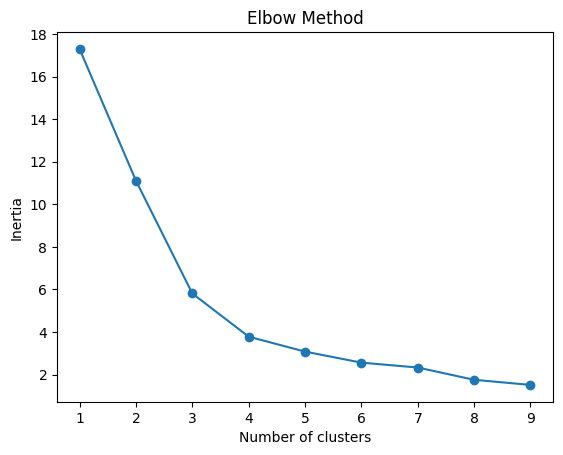

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Create some random 2D data
np.random.seed(42)
X = np.random.rand(100, 2)  # 100 points, 2 features

# Elbow method
inertia = []
K_range = range(1, 10)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [12]:
df.head()

,PuzzleId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,GameUrl,OpeningTags,SortKey
0,tewjc,r5k1/pp3p1p/2b2qp1/3pr3/8/4P2P/R1PN1PP1/Q3K2R ...,a2a7 e5e3 f2e3 f6a1 a7a1 a8a1,1493,76,94,18768,crushing discoveredAttack long middlegame xRay...,https://lichess.org/SLbfzQtP#36,Polish_Opening Polish_Opening_Other_variations,1764192
1,0kDWS,1r6/1PN5/3p4/4kpp1/1R6/P3n3/K1P5/8 b - - 0 49,e3d5 b4b5 b8b7 b5b7,1947,75,95,13691,advantage endgame pin short,https://lichess.org/q2SFqfYD/black#97,NaN,1300645
2,f2p5F,5r2/p3R2p/4Q1p1/3B2k1/2p2b2/2P2P2/P5P1/1q3K2 w...,e6e1 b1d3 f1f2 d3d5,1385,75,96,16934,advantage endgame fork short,https://lichess.org/BTADpsgd#76,NaN,1625664
3,LDIfb,rnbqkb1r/pp2pp1p/3p1np1/2p5/4P3/2P2N1P/PP1PBPP...,f6e4 d1a4 b8c6 a4e4,1472,75,95,21527,advantage fork opening short,https://lichess.org/hnuvOm1w/black#9,Sicilian_Defense Sicilian_Defense_Modern_Varia...,2045065
4,mJDcO,5rk1/p1Q3pp/8/3p4/3q1r2/8/P1P3PP/R4R1K w - - 0 21,f1f4 d4a1 f4f1 a1f1,1321,76,95,17352,endgame hangingPiece mate mateIn2 short,https://lichess.org/oAkUCwh7#40,NaN,1648440


In [13]:
print(df.shape)
print(X.shape)

(1000, 11)
(100, 2)


In [14]:
len(df)  # should equal X.shape[0] if assigning directly

1000

In [16]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans

# Example text data
documents = [
    "I love pizza",
    "I hate pizza",
    "Python is great",
    "I enjoy coding in Python",
    "Pizza is amazing"
]

# 1️⃣ Fit the vectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(documents)  # fit_transform fits AND transforms your data

# 2️⃣ Fit KMeans
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)

# 3️⃣ Get feature names (words)
terms = vectorizer.get_feature_names_out()

# 4️⃣ Print top 10 keywords per cluster
for i in range(k):
    center_terms = kmeans.cluster_centers_[i].argsort()[-10:]  # top 10 terms
    print(f"\nCluster {i} keywords:")
    print([terms[ind] for ind in center_terms])


Cluster 0 keywords:
['coding', 'enjoy', 'in', 'amazing', 'great', 'hate', 'love', 'python', 'is', 'pizza']

Cluster 1 keywords:
['amazing', 'great', 'hate', 'is', 'love', 'pizza', 'coding', 'enjoy', 'in', 'python']


In [17]:
df.to_csv("puzzles_clustered.csv", index=False)